# Lecture 08 – Regresión con Red Neuronal Profunda (DNN)
### Universidad EAFIT | 2026 | Introduccion a la Inteligencia Artificial 

---

## Clasificación vs. Regresión con DNNs

En los notebooks anteriores (`YourFirstDeepNN_torch` y `YourFirst_DNN-CNN_Keras`) el objetivo era **clasificar** una entrada en una de $K$ categorías discretas. La capa de salida tenía $K$ neuronas con activación **Softmax**.

En este notebook el objetivo es **regresión**: predecir un valor numérico continuo — el salario semanal (`Wage`) de jugadores de FIFA 21.

| Aspecto | Clasificación | **Regresión** |
|---------|--------------|---------------|
| Salida | $K$ neuronas + Softmax | **1 neurona, sin activación** |
| Función de pérdida | Cross-Entropy | **MSE** (Mean Squared Error) |
| Métrica principal | Accuracy | **MAE / R²** |
| Interpretación | $P(y_k \mid x)$ | $\hat{y} \in \mathbb{R}$ |

La arquitectura de la red es casi idéntica — solo cambia lo que ocurre **en la última capa** y **en la función de pérdida**. El forward pass, el backpropagation y el optimizador funcionan exactamente igual.

---

## Dataset: FIFA 21 Players

Usaremos un subconjunto del dataset de jugadores de FIFA 21. El objetivo es predecir el **salario semanal** (`Wage`) de cada jugador a partir de sus atributos: edad, valoración general, habilidades técnicas, posición, etc.

Este es un problema de regresión sobre datos tabulares, diferente a las imágenes de MNIST/Fashion MNIST. Las DNNs funcionan bien en ambos dominios, pero el preprocesamiento y las métricas de evaluación son distintos.

---
## 0. Configuración del Entorno

Instalación y carga de dependencias. A diferencia de los notebooks de clasificación, aquí añadimos **pandas** para manejar datos tabulares.

In [ ]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install pandas scikit-learn tensorflow matplotlib
pass

In [22]:
import pandas as pd                              # Manipulación de datos tabulares (DataFrames)
from matplotlib import pyplot as plt             # Visualización

from sklearn.model_selection import train_test_split   # División estratificada de datos
from sklearn.metrics import r2_score, mean_absolute_error  # Métricas de regresión

from tensorflow import keras                     # API de alto nivel de TensorFlow

# Semilla para reproducibilidad de splits y pesos iniciales
random_state = 42

plt.rc('font', family='serif', size=12)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga y Exploración de Datos

### Datos tabulares vs. imágenes

En los notebooks anteriores, cada muestra era un vector de **784 píxeles homogéneos** (todos del mismo tipo: intensidad de gris). Aquí cada muestra es un **vector de 61 features heterogéneas**: mezcla de enteros (edad, valoración), flotantes (potencial) y categóricas (pie preferido).

Esto requiere un **preprocesamiento más cuidadoso** antes de alimentar los datos a la red:
- Tratar **valores faltantes** (`NaN`)
- **Codificar** variables categóricas a numéricas
- **Normalizar** las features (lo hará `BatchNormalization` dentro de la red)

### Variable objetivo: `Wage`

El salario semanal en euros es nuestra variable a predecir ($y$). Es una variable continua y positiva con distribución asimétrica (pocos jugadores de élite ganan mucho, la mayoría gana poco) — un escenario típico y realista en regresión.

In [ ]:
# Cargamos el dataset desde el archivo CSV local.
# header=0: la primera fila contiene los nombres de las columnas.
data = pd.read_csv('data/players_2021.csv', header=0)

print(f'Shape del dataset: {data.shape}  → ({data.shape[0]} jugadores, {data.shape[1]} columnas)')
print(f'\nColumnas: {list(data.columns)}')
data.head()

Shape del dataset: (15926, 63)  → (15926 jugadores, 63 columnas)

Columnas: ['Name', 'Age', 'Overall', 'Wage', 'Preferred Foot', 'International Reputation', 'Weak Foot', 'Skill Moves', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle']


,Name,Age,Overall,Wage,Preferred Foot,International Reputation,Weak Foot,Skill Moves,LS,ST,...,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle
0,L. Messi,31,94,565000,Left,5.0,4.0,4.0,90.0,90.0,...,94.0,48.0,22.0,94.0,94.0,75.0,96.0,33.0,28.0,26.0
1,Cristiano Ronaldo,33,94,405000,Right,5.0,4.0,5.0,94.0,94.0,...,93.0,63.0,29.0,95.0,82.0,85.0,95.0,28.0,31.0,23.0
2,Neymar Jr,26,92,290000,Right,5.0,5.0,5.0,87.0,87.0,...,82.0,56.0,36.0,89.0,87.0,81.0,94.0,27.0,24.0,33.0
3,K. De Bruyne,27,91,355000,Right,4.0,5.0,4.0,85.0,85.0,...,91.0,76.0,61.0,87.0,94.0,79.0,88.0,68.0,58.0,51.0
4,E. Hazard,27,91,340000,Right,4.0,4.0,4.0,86.0,86.0,...,80.0,54.0,41.0,87.0,89.0,86.0,91.0,34.0,27.0,22.0


In [3]:
data.describe(include='all')# Útil para detectar outliers (ej: salarios extremos) y entender el rango de cada feature.

,Name,Age,Overall,Wage,Preferred Foot,International Reputation,Weak Foot,Skill Moves,LS,ST,...,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle
count,15926,15926.000000,15926.000000,15926.000000,15926,15926.000000,15926.000000,15926.000000,15926.000000,15926.000000,...,15926.000000,15926.000000,15926.000000,15926.000000,15926.000000,15926.000000,15926.00000,15926.000000,15926.000000,15926.000000
unique,15114,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,J. Rodríguez,NaN,NaN,NaN,Right,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,9,NaN,NaN,NaN,11969,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,24.991209,66.446189,10254.866256,NaN,1.116037,3.004081,2.533342,59.842647,59.842647,...,51.446126,59.575411,50.401168,54.844405,55.494726,52.118234,60.34654,51.273703,51.883021,49.593118
std,NaN,4.552866,6.809244,22692.769542,NaN,0.397762,0.636845,0.618186,9.141407,9.141407,...,15.718376,14.432944,18.797738,14.665434,12.897478,12.501841,10.14202,17.198926,19.161875,19.162508
min,NaN,16.000000,46.000000,1000.000000,NaN,1.000000,1.000000,2.000000,33.000000,33.000000,...,11.000000,13.000000,10.000000,11.000000,12.000000,12.000000,29.00000,10.000000,10.000000,10.000000
25%,NaN,21.000000,62.000000,1000.000000,NaN,1.000000,3.000000,2.000000,54.000000,54.000000,...,40.000000,50.000000,34.000000,46.000000,47.000000,42.000000,53.00000,37.000000,35.000000,32.000000
50%,NaN,25.000000,66.000000,3000.000000,NaN,1.000000,3.000000,2.000000,60.000000,60.000000,...,54.000000,61.000000,56.000000,57.000000,57.000000,52.000000,61.00000,56.000000,59.000000,56.000000
75%,NaN,28.000000,71.000000,10000.000000,NaN,1.000000,3.000000,3.000000,66.000000,66.000000,...,64.000000,70.000000,65.000000,65.000000,65.000000,61.000000,68.00000,65.000000,67.000000,65.000000


In [5]:
# Revisamos la distribución de la variable categórica 'Preferred Foot'.
print('Distribución de Preferred Foot:')
print(data['Preferred Foot'].value_counts()) # Solo tiene dos valores, la codificaremos como binaria (0/1) en el preprocesamiento.


# Revisamos cuántos valores faltantes hay por columna
missing = data.isnull().sum()
print(f'\nColumnas con NaN: {missing[missing > 0].to_dict()}')

Distribución de Preferred Foot:
Preferred Foot
Right    11969
Left      3957
Name: count, dtype: int64

Columnas con NaN: {}


---
## 2. Preprocesamiento de Datos

### Pasos necesarios

1. **Eliminar filas con `NaN`**: la red neuronal no puede procesar valores faltantes
2. **Codificar `Preferred Foot`**: convertir 'Right'/'Left' → 0/1 (one-hot no es necesario para variables binarias)



In [6]:
# Paso 1: eliminar filas con cualquier valor faltante.

data.dropna(axis=0, how='any', inplace=True) #axis=0: opera sobre filas,how='any' elimina si hay al menos 1 NaN, inplace=True modifica el DataFrame original sin crear uno nuevo.
print(f'Filas tras eliminar NaN: {len(data)}')

Filas tras eliminar NaN: 15926


In [7]:
# Paso 2: codificar 'Preferred Foot' como variable binaria.
# Right → 0, Left → 1  (elección arbitraria; lo importante es la consistencia)
# La red aprenderá si esta distinción es relevante para predecir el salario.
data.loc[:, 'Preferred Foot'] = (
    data['Preferred Foot'].map({'Right': 0, 'Left': 1}).astype('int64')
)

# Aseguramos que la columna sea numérica (por si quedaron valores no mapeados)
data['Preferred Foot'] = pd.to_numeric(data['Preferred Foot'], errors='coerce')

# Reseteamos el índice para que sea contiguo tras los drops
data.reset_index(drop=True, inplace=True)

print('Codificación completada.')
print(f'Valores únicos en Preferred Foot: {sorted(data["Preferred Foot"].unique())}')

Codificación completada.
Valores únicos en Preferred Foot: [np.int64(0), np.int64(1)]


---
## 3. División Train / Validation / Test

Usamos la misma estrategia de tres conjuntos que en `ClasificacionDNNKeras`, pero con proporciones **70 / 15 / 15** 

| Conjunto | Proporción | Uso |
|----------|-----------|-----|
| **Train** | 70% | Ajustar pesos de la red |
| **Validation** | 15% | Monitorear generalización durante el entrenamiento |
| **Test** | 15% | Evaluación final honesta (datos nunca vistos) |

> **Nota**: Excluimos la columna `Name` al definir `X` porque es un identificador textual sin poder predictivo numérico. La columna `Wage` es nuestra variable objetivo $y$.

### Normalización: BatchNormalization dentro del modelo

A diferencia del notebook de clasificación donde normalizamos manualmente con `÷255`, aquí la normalización se realiza **dentro de la red** con capas `BatchNormalization`. Esto es especialmente útil cuando las features tienen escalas muy distintas (edad: 16-45, valoración: 46-94, potencial: 48-95...) y elimina la necesidad de un preprocesamiento externo separado.

In [13]:
# División 70% entrenamiento / 30% (val+test)
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(columns=['Name', 'Wage']),   # Features: todas las columnas menos nombre y target
    data['Wage'],                           # Target: salario semanal a predecir
    test_size=0.3,                          # 30% para val+test
    random_state=random_state
)

# División del 30% restante: mitad validación, mitad prueba → 15% cada uno
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test,
    test_size=0.5,
    random_state=random_state
)

print(f'Entrenamiento : {X_train.shape[0]:>5,} muestras  ({X_train.shape[0]/len(data)*100:.0f}%)')
print(f'Validación    : {X_val.shape[0]:>5,} muestras  ({X_val.shape[0]/len(data)*100:.0f}%)')
print(f'Prueba        : {X_test.shape[0]:>5,} muestras  ({X_test.shape[0]/len(data)*100:.0f}%)')
print(f'\nFeatures por muestra : {X_train.shape[1]}')
print(f'Rango de Wage (train) : [{y_train.min():,.0f} €, {y_train.max():,.0f} €]')

Entrenamiento : 11,148 muestras  (70%)
Validación    : 2,389 muestras  (15%)
Prueba        : 2,389 muestras  (15%)

Features por muestra : 61
Rango de Wage (train) : [1,000 €, 455,000 €]


In [14]:
# Revisamos los tipos de datos de las features.
# Todas deben ser numéricas antes de pasarlas a la red neuronal.
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11148 entries, 6428 to 7270
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       11148 non-null  int64  
 1   Overall                   11148 non-null  int64  
 2   Preferred Foot            11148 non-null  int64  
 3   International Reputation  11148 non-null  float64
 4   Weak Foot                 11148 non-null  float64
 5   Skill Moves               11148 non-null  float64
 6   LS                        11148 non-null  float64
 7   ST                        11148 non-null  float64
 8   RS                        11148 non-null  float64
 9   LW                        11148 non-null  float64
 10  LF                        11148 non-null  float64
 11  CF                        11148 non-null  float64
 12  RF                        11148 non-null  float64
 13  RW                        11148 non-null  float64
 14  LAM      

---
## 4. Definición del Modelo

### Diferencia clave: capa de salida para regresión

La única diferencia arquitectónica fundamental entre una DNN de clasificación y una de regresión está en la **última capa**:

```python
# Clasificación (K clases)       # Regresión
Dense(K, activation='softmax')   Dense(1)   # 1 neurona, sin activación
```

Sin activación en la salida, la neurona puede producir cualquier valor real $\hat{y} \in (-\infty, +\infty)$, necesario para predecir un salario continuo.

### Novedad: BatchNormalization

En este modelo añadimos capas `BatchNormalization` que **no estaban en los notebooks anteriores**. Su función: normalizar la salida de cada capa para que tenga media ≈ 0 y varianza ≈ 1:

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$

donde $\mu_B$ y $\sigma_B^2$ son la media y varianza del mini-batch, y $\gamma, \beta$ son parámetros **aprendibles**.

**Beneficios de BatchNorm**:
- Estabiliza el entrenamiento cuando las features tienen escalas muy distintas
- Actúa como regularizador implícito (reduce overfitting)
- Permite usar learning rates más altos
- Reduce la sensibilidad a la inicialización de pesos

Aquí usamos `BatchNormalization` **antes de la primera capa Dense** como normalizador de entrada (reemplaza el `÷255` manual), y **entre capas** para estabilizar el entrenamiento.

### Arquitectura

```
Input(61) → BN → Dense(16,tanh) → BN → Dense(8,tanh,L2) → BN → Dense(8,tanh,L2) → BN → Dense(1)
```

La red es **más estrecha** que en clasificación (16→8→8 vs 128→64→64→32) porque el problema de regresión tiene menos complejidad en la salida (1 valor vs 10 clases).

In [15]:
# Definimos el modelo de regresión con BatchNormalization.
model = keras.Sequential([

    # --- Capa de normalización de entrada ---
    # BatchNormalization como primera capa: normaliza las 61 features de entrada
    # (media≈0, varianza≈1) sin necesidad de preprocesamiento externo.
    # Equivale a un StandardScaler aprendible dentro de la red.
    keras.layers.BatchNormalization(input_shape=(61,)),

    # --- Capa oculta 1 ---
    # 16 neuronas con activación tanh. Sin regularización en la primera capa
    # porque BatchNorm ya actúa como regulador.
    keras.layers.Dense(16, activation='tanh'),

    # BatchNorm entre capas: normaliza las activaciones antes de pasarlas
    # a la siguiente capa, estabilizando el flujo de gradientes.
    keras.layers.BatchNormalization(),

    # --- Capa oculta 2 ---
    # 8 neuronas + regularización L2 con λ=1 (relativamente agresiva).
    # L2 penaliza pesos grandes: L_total = L_MSE + 1 * Σ w_i²
    keras.layers.Dense(8, activation='tanh', kernel_regularizer=keras.regularizers.L2(1)),
    keras.layers.BatchNormalization(),

    # --- Capa oculta 3 ---
    keras.layers.Dense(8, activation='tanh', kernel_regularizer=keras.regularizers.L2(1)),
    keras.layers.BatchNormalization(),

    # --- Capa de salida ---
    # UNA sola neurona, SIN función de activación.
    # Produce directamente el valor predicho ŷ ∈ ℝ (el salario).
    # En clasificación esta capa tenía K neuronas + softmax.
    keras.layers.Dense(1),
])

model.summary()

c:\Users\yomin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 61)             │           244 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581 (6.18 KB)

 Trainable params: 1,395 (5.45 KB)

 Non-trainable params: 186 (744.00 B)

---
## 5. Compilación: Métricas y Pérdida para Regresión

### Función de pérdida: MSE

Para regresión usamos **Mean Squared Error** en lugar de Cross-Entropy:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

El MSE penaliza más los **errores grandes** (por el cuadrado) y tiene gradiente continuo → ideal para backpropagation. Su unidad es €² — difícil de interpretar directamente, de ahí que monitoreemos MAE como métrica adicional.

### Métrica: MAE

El **Mean Absolute Error** es más interpretable:

$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

Si `MAE = 5000`, el modelo se equivoca en promedio **±5,000 € por semana** en sus predicciones.

### Métrica de evaluación final: R²

El **coeficiente de determinación** mide qué proporción de la varianza del target explica el modelo:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} \in (-\infty, 1]$$

| R² | Interpretación |
|-----|----------------|
| 1.0 | Predicción perfecta |
| 0.9 | El modelo explica el 90% de la varianza |
| 0.0 | Equivale a predecir siempre la media $\bar{y}$ |
| < 0 | Peor que predecir la media (modelo inútil) |

In [16]:
# Compilamos el modelo de regresión.
# La diferencia clave con clasificación: loss='mse' en lugar de 'sparse_categorical_crossentropy'
model.compile(
    # MSE como función de pérdida para regresión.
    # Diferenciable en todo punto → compatible con backpropagation.
    loss='mse',

    # Adam con lr=0.01 — más alto que en clasificación (0.0005-0.001).
    # BatchNorm estabiliza el entrenamiento, permitiendo lr más agresivos.
    optimizer=keras.optimizers.Adam(learning_rate=0.01),

    # MAE como métrica de monitoreo: más interpretable que MSE (mismas unidades que Wage).
    # No afecta el entrenamiento — solo se reporta para seguimiento.
    metrics=['mae']
)

print('Modelo compilado.')
print('  Loss     : MSE  (para entrenar — minimizar errores cuadráticos)')
print('  Métrica  : MAE  (para monitorear — interpretable en €/semana)')

Modelo compilado.
  Loss     : MSE  (para entrenar — minimizar errores cuadráticos)
  Métrica  : MAE  (para monitorear — interpretable en €/semana)


---
## 6. Entrenamiento

Entrenamos por **500 épocas** — significativamente más que en clasificación (100 épocas). Esto es habitual en regresión sobre datos tabulares:
- Las relaciones entre features y target son más complejas y continuas
- El modelo necesita más iteraciones para aprender la escala del target (salarios)
- BatchNorm y L2 regularization reducen el riesgo de overfitting en epochs largas

> `validation_batch_size=len(X_val)`: evaluamos el conjunto de validación completo en un solo paso (no en mini-batches). Esto es posible porque la validación no requiere gradientes y el dataset de val cabe en memoria.

In [17]:
%%time
# Entrenamiento del modelo de regresión.
# El ciclo interno es idéntico al de clasificación:
# mini-batch → forward → MSE loss → backward → Adam update
model.fit(
    X_train, y_train,
    epochs=500,                              # 500 épocas — más que clasificación
    batch_size=1024,                         # Mini-batches de 1024 muestras
    validation_data=(X_val, y_val),          # Monitoreo en validación cada epoch
    validation_batch_size=len(X_val)         # Validación en un solo batch (sin gradientes)
)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 607518976.0000 - mae: 10193.3545 - val_loss: 692396928.0000 - val_mae: 10377.2129
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 607446976.0000 - mae: 10192.7617 - val_loss: 692379776.0000 - val_mae: 10376.5254
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 607361344.0000 - mae: 10191.9102 - val_loss: 692419968.0000 - val_mae: 10378.4375
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 607245824.0000 - mae: 10190.7344 - val_loss: 692492928.0000 - val_mae: 10381.8496
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 607103616.0000 - mae: 10189.1865 - val_loss: 692514240.0000 - val_mae: 10382.8818
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 606939008.0000 - mae: 10187.2510 - val_loss: 692540416.0000 - val_mae: 10384.3340
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 606750976.0000 - mae: 10184.8799 - val_loss: 692479552.0000 - val_mae: 10381.7539
Epoch 8/500


---
## 7. Curvas de Aprendizaje (MAE)

A diferencia de los notebooks de clasificación donde graficamos **accuracy** y **loss**, aquí graficamos solo el **MAE** (más interpretable: está en las mismas unidades que el target, €).

**¿Qué buscar en las curvas?**

- **Convergencia**: el MAE debe decrecer y estabilizarse — no oscilar permanentemente
- **Gap train/val**: un gap pequeño indica buena generalización; uno grande indica overfitting
- **Val MAE sube mientras train MAE baja**: señal clara de overfitting

El comportamiento esperado con BatchNorm + L2 es que el gap train/val sea moderado, dado que ambas técnicas de regularización limitan la capacidad del modelo de memorizar.

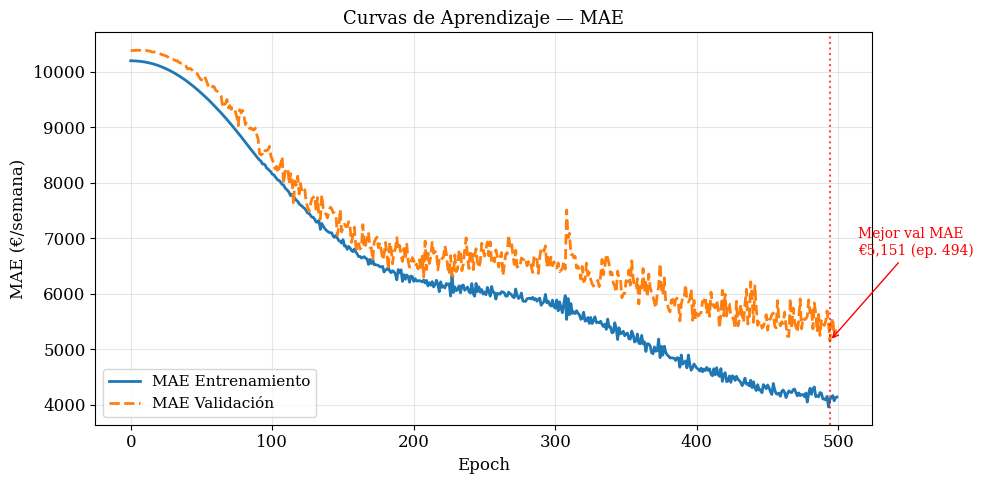

In [18]:
# Graficamos el MAE de entrenamiento y validación por época.
# model.history.history contiene todas las métricas registradas durante el fit().
history = model.history.history

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['mae'],     label='MAE Entrenamiento', linewidth=2)
ax.plot(history['val_mae'], label='MAE Validación',    linewidth=2, linestyle='--')

# Marcamos la época con menor MAE de validación
best_epoch = history['val_mae'].index(min(history['val_mae']))
best_val_mae = min(history['val_mae'])
ax.axvline(best_epoch, color='red', linestyle=':', alpha=0.7)
ax.annotate(f'Mejor val MAE\n€{best_val_mae:,.0f} (ep. {best_epoch})',
            xy=(best_epoch, best_val_mae),
            xytext=(best_epoch + 20, best_val_mae * 1.3),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_xlabel('Epoch', size=12)
ax.set_ylabel('MAE (€/semana)', size=12)
ax.set_title('Curvas de Aprendizaje — MAE', size=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Evaluación del Modelo

Evaluamos el modelo con dos métricas complementarias sobre los tres conjuntos:

- **R²** (coeficiente de determinación): ¿qué proporción de la varianza explica el modelo?
- **MAE** (error absoluto medio): ¿cuánto se equivoca en promedio, en €/semana?

Comparar train/val/test nos dice:
- Si **R²_train >> R²_test** → overfitting
- Si **R²_train ≈ R²_test ≈ R²_val** → buena generalización
- Si todos los R² son bajos → underfitting (modelo muy simple o pocas épocas)

In [19]:
# Evaluación con R² y MAE sobre los tres conjuntos.
# model.predict() devuelve un array de shape (N, 1) → flatten() lo convierte a (N,)
for name, X, y in [('Entrenamiento', X_train, y_train),
                   ('Validación',    X_val,   y_val),
                   ('Prueba',        X_test,  y_test)]:
    y_hat = model.predict(X, verbose=0).flatten()     # Predicciones ŷ
    r2  = r2_score(y, y_hat)                          # R²: proporción de varianza explicada
    mae = mean_absolute_error(y, y_hat)               # MAE: error medio en €/semana
    print(f'{name:15s} | R² = {r2:.4f} | MAE = €{mae:,.0f}/semana')

Entrenamiento   | R² = 0.8953 | MAE = €3,749/semana
Validación      | R² = 0.7252 | MAE = €5,198/semana
Prueba          | R² = 0.6890 | MAE = €5,231/semana


---
## 9. Análisis del Error de Predicción

Más allá de las métricas agregadas, conviene inspeccionar **la distribución del error**:

$$e_i = y_i - \hat{y}_i$$

Un modelo bien calibrado debería producir errores que:
- Se centren alrededor de **0** (sin sesgo sistemático)
- Tengan una distribución **aproximadamente simétrica** (gaussiana ideal)
- No tengan **outliers extremos** consistentes en una sola dirección

Si el histograma está sesgado hacia valores positivos → el modelo **subestima** los salarios.
Si está sesgado hacia negativos → **sobreestima**.

Esta asimetría es esperable aquí: los jugadores de élite con salarios muy altos son atípicos y difíciles de predecir correctamente con una DNN pequeña.

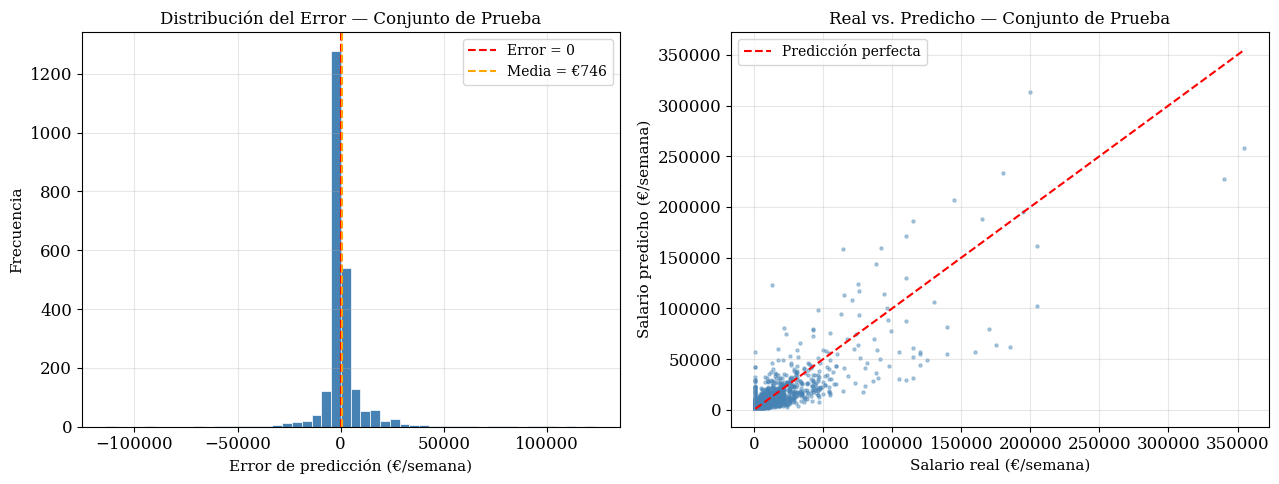

In [20]:
# Histograma de errores de predicción en el conjunto de prueba.
# Error = Salario real - Salario predicho
# Distribución ideal: campana centrada en 0 (sin sesgo)
y_hat_test = model.predict(X_test, verbose=0).flatten()
errors = y_test.values - y_hat_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma del error
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Error = 0')
axes[0].axvline(errors.mean(), color='orange', linewidth=1.5, linestyle='--',
                label=f'Media = €{errors.mean():,.0f}')
axes[0].set_xlabel('Error de predicción (€/semana)', size=11)
axes[0].set_ylabel('Frecuencia', size=11)
axes[0].set_title('Distribución del Error — Conjunto de Prueba', size=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Scatter: salario real vs. predicho (diagonal perfecta = modelo perfecto)
axes[1].scatter(y_test, y_hat_test, s=5, alpha=0.4, color='steelblue')
lims = [min(y_test.min(), y_hat_test.min()), max(y_test.max(), y_hat_test.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_xlabel('Salario real (€/semana)', size=11)
axes[1].set_ylabel('Salario predicho (€/semana)', size=11)
axes[1].set_title('Real vs. Predicho — Conjunto de Prueba', size=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Tabla comparativa: salario real vs. predicho para todos los jugadores.
# Útil para identificar casos específicos donde el modelo falla.
all_predictions = model.predict(data.drop(columns=['Name', 'Wage']), verbose=0).flatten()

result_df = pd.concat([
    data[['Name']].reset_index(drop=True),            # Nombre del jugador
    data['Wage'].reset_index(drop=True),               # Salario real
    pd.DataFrame({'Wage_predicho': all_predictions.round(0).astype(int)})  # Predicción
], axis=1)

# Calculamos el error absoluto por jugador
result_df['Error_abs'] = (result_df['Wage'] - result_df['Wage_predicho']).abs()
result_df.sort_values('Error_abs', ascending=False).head(20)

,Name,Wage,Wage_predicho,Error_abs
0,L. Messi,565000,371597,193403
111,Carvajal,185000,61537,123463
167,Nacho Fernández,180000,59829,120171
17,E. Cavani,200000,313701,113701
27,Coutinho,340000,227184,112816
59,Azpilicueta,175000,64022,110978
796,L. López,13000,123374,110374
123,M. Mandžukić,160000,57011,102989
73,R. Mahrez,205000,102116,102884
330,C. Smalling,130000,30223,99777


---
## 10. Conclusiones

### Resumen: Clasificación vs. Regresión con DNNs

| Aspecto | Clasificación (`ClasificacionDNNKeras`) | **Regresión (este notebook)** |
|---------|----------------------------------------|-------------------------------|
| Dataset | Fashion MNIST (imágenes) | FIFA 19 Players (tabular) |
| Target | 10 categorías discretas | Wage continuo (€/semana) |
| Capa de salida | `Dense(10, activation='softmax')` | **`Dense(1)`** (sin activación) |
| Loss | `sparse_categorical_crossentropy` | **`mse`** |
| Métrica | `accuracy` | **`mae`, `r2_score`** |
| Normalización | Manual (`÷255`) | **`BatchNormalization`** dentro del modelo |
| Épocas | 100 | **500** |

### ¿Por qué los salarios son difíciles de predecir?

La distribución de salarios en fútbol es **muy asimétrica**: la mayoría de jugadores gana poco y unos pocos ganan muchísimo. Esto hace que:
- El MSE penalice desproporcionadamente los errores en jugadores de élite
- El modelo tienda a **subestimar** los salarios más altos (difícil generalizar outliers)
- Un R² moderado (~0.8-0.9) ya es un resultado razonable

### Experimentos sugeridos

- **Cambia la función de pérdida**: prueba `mae` en lugar de `mse` — ¿el modelo es más robusto a outliers de salario?
- **Más neuronas**: dobla el tamaño de las capas ocultas (16→32, 8→16) y compara R²
- **Dropout**: añade `keras.layers.Dropout(0.2)` para regularización adicional
- **Transforma el target**: prueba predecir `log(Wage)` en lugar de `Wage` — la distribución log-normal podría ser más fácil de aprender
- **Feature engineering**: ¿qué columnas contribuyen más? Prueba entrenar sin algunas features y observa el impacto en MAE